# ResNet Top-1 vs Bits Comparison

This notebook compares ImageNet top-1 accuracy for three methods on the same plot:

- Baseline quantization
- AdaRound
- NWC

Change `MODEL_NAME`, `AIMET_SWEEP_DIR`, and `NWC_SWEEP_DIR` in the first code cell to switch between ResNet18 and ResNet50 experiments.

In [26]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

# MODEL_NAME = "Resnet18"

# ResNet18 example
# AIMET_SWEEP_DIR = Path("/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_weight_only_bw_sweep_2026-03-28-20-49-28")
# NWC_SWEEP_DIR = Path("/home/jgryu/workspace/weight_compression/comp_cnn/resnet18_nwc_lambda_sweep_ql_ldlq4")

# ResNet50 example: replace the two paths below with your actual result directories.
MODEL_NAME = "Resnet50"
AIMET_SWEEP_DIR = Path("/home/jgryu/workspace/weight_compression/comp_cnn/resnet_weight_only_bw_sweep_2026-03-28-22-37-17")
NWC_SWEEP_DIR = Path("/home/jgryu/workspace/weight_compression/comp_cnn/resnet50_nwc_lambda_sweep_ql_ldlq4")

AIMET_RESULTS_CSV = AIMET_SWEEP_DIR / "results.csv"
NWC_RESULTS_CSV = NWC_SWEEP_DIR / "sweep_results.csv"

assert AIMET_RESULTS_CSV.is_file(), AIMET_RESULTS_CSV
assert NWC_RESULTS_CSV.is_file(), NWC_RESULTS_CSV

AIMET_RESULTS_CSV, NWC_RESULTS_CSV


(PosixPath('/home/jgryu/workspace/weight_compression/comp_cnn/resnet_weight_only_bw_sweep_2026-03-28-22-37-17/results.csv'),
 PosixPath('/home/jgryu/workspace/weight_compression/comp_cnn/resnet50_nwc_lambda_sweep_ql_ldlq4/sweep_results.csv'))

In [27]:
aimet_df = pd.read_csv(AIMET_RESULTS_CSV).sort_values("weight_bw").reset_index(drop=True)
nwc_df = pd.read_csv(NWC_RESULTS_CSV).sort_values("estimated_bits_per_param").reset_index(drop=True)

nwc_bit_col = "actual_bits_per_param"
if nwc_bit_col not in nwc_df.columns or not nwc_df[nwc_bit_col].notna().any():
    nwc_bit_col = "estimated_bits_per_param"

baseline_plot = aimet_df[["weight_bw", "baseline_weight_only_top1"]].rename(
    columns={"weight_bw": "bits_per_param", "baseline_weight_only_top1": "top1"}
)
baseline_plot["method"] = "Baseline Quant"

adaround_plot = aimet_df[["weight_bw", "adaround_weight_only_top1"]].rename(
    columns={"weight_bw": "bits_per_param", "adaround_weight_only_top1": "top1"}
)
adaround_plot["method"] = "AdaRound"

nwc_plot = nwc_df[[nwc_bit_col, "compressed_top1", "lambda_tag"]].dropna().rename(
    columns={nwc_bit_col: "bits_per_param", "compressed_top1": "top1"}
)
nwc_plot["method"] = "NWC"

fp32_candidates = []
if "fp32_top1" in aimet_df.columns and aimet_df["fp32_top1"].notna().any():
    fp32_candidates.append(float(aimet_df["fp32_top1"].mean()))
if "fp32_top1" in nwc_df.columns and nwc_df["fp32_top1"].notna().any():
    fp32_candidates.append(float(nwc_df["fp32_top1"].mean()))
fp32_top1 = sum(fp32_candidates) / len(fp32_candidates)

print(f"MODEL_NAME = {MODEL_NAME}")
print(f"Using NWC x-axis column: {nwc_bit_col}")
print(f"FP32 top-1 reference: {fp32_top1:.4f}")

display(aimet_df)
display(nwc_df[["lambda_tag", nwc_bit_col, "compressed_top1", "top1_drop"]])


MODEL_NAME = Resnet50
Using NWC x-axis column: estimated_bits_per_param
FP32 top-1 reference: 80.6742


,weight_bw,fp32_top1,baseline_weight_only_top1,adaround_weight_only_top1,baseline_drop,adaround_drop,adaround_gain,elapsed_sec
0,2,80.4964,0.0877,28.8823,80.4087,51.6140,28.7946,1854.21
1,3,80.4964,0.1116,74.0055,80.3848,6.4909,73.8939,1817.35
2,4,80.4964,56.0679,78.7006,24.4285,1.7958,22.6327,1837.25
3,5,80.4964,71.6830,79.9225,8.8134,0.5739,8.2395,1858.02
4,6,80.4964,79.4420,80.3001,1.0544,0.1963,0.8581,1818.71


,lambda_tag,estimated_bits_per_param,compressed_top1,top1_drop
0,lmbda10,1.4739,15.096,65.756
1,lmbda30,2.2486,0.174,80.678
2,lmbda50,2.6044,0.136,80.716
3,lmbda75,2.8913,0.114,80.738
4,lmbda100,3.0933,0.100,80.752
5,lmbda300,3.8897,0.218,80.634
6,lmbda1000,4.7407,70.644,10.208


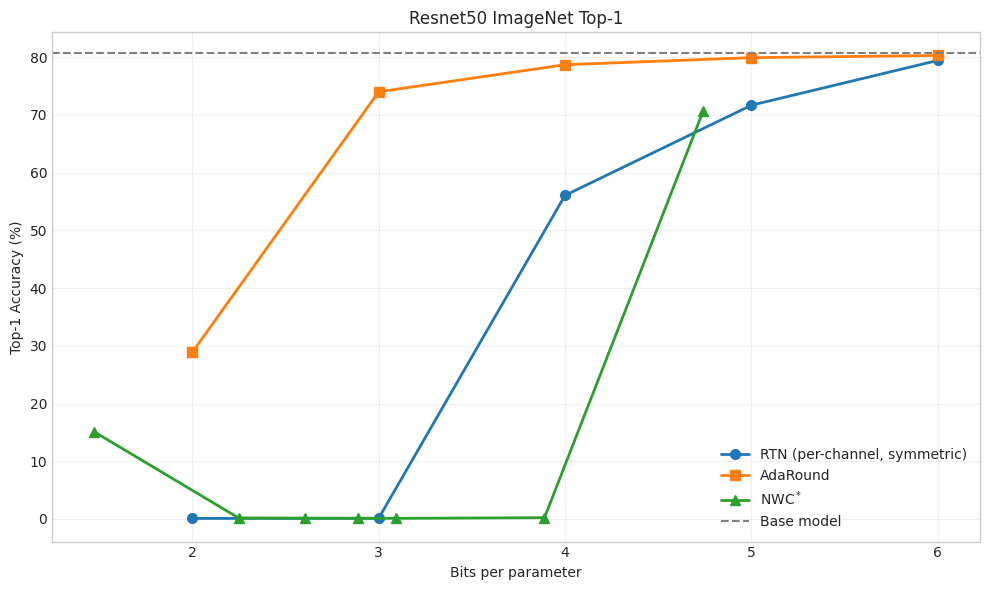

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    baseline_plot["bits_per_param"],
    baseline_plot["top1"],
    marker="o",
    linewidth=2,
    markersize=7,
    label="RTN (per-channel, symmetric)",
)
ax.plot(
    adaround_plot["bits_per_param"],
    adaround_plot["top1"],
    marker="s",
    linewidth=2,
    markersize=7,
    label="AdaRound",
)
ax.plot(
    nwc_plot["bits_per_param"],
    nwc_plot["top1"],
    marker="^",
    linewidth=2,
    markersize=7,
    label=r"NWC$^*$",
)

# for _, row in nwc_plot.iterrows():
#     ax.annotate(
#         row["lambda_tag"],
#         (row["bits_per_param"], row["top1"]),
#         textcoords="offset points",
#         xytext=(5, 5),
#         fontsize=8,
#     )

ax.axhline(
    fp32_top1,
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label=f"Base model",
)

ax.set_title(f"{MODEL_NAME} ImageNet Top-1")
ax.set_xlabel("Bits per parameter")
ax.set_ylabel("Top-1 Accuracy (%)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [29]:
comparison_df = pd.concat([
    baseline_plot.assign(label=baseline_plot["bits_per_param"].map(lambda x: f"W{int(x)}")),
    adaround_plot.assign(label=adaround_plot["bits_per_param"].map(lambda x: f"W{int(x)}")),
    nwc_plot.assign(label=nwc_plot["lambda_tag"]),
], ignore_index=True)

comparison_df = comparison_df[["method", "label", "bits_per_param", "top1"]].sort_values(
    ["method", "bits_per_param"]
).reset_index(drop=True)
comparison_df


,method,label,bits_per_param,top1
0,AdaRound,W2,2.0000,28.8823
1,AdaRound,W3,3.0000,74.0055
2,AdaRound,W4,4.0000,78.7006
3,AdaRound,W5,5.0000,79.9225
4,AdaRound,W6,6.0000,80.3001
5,Baseline Quant,W2,2.0000,0.0877
6,Baseline Quant,W3,3.0000,0.1116
7,Baseline Quant,W4,4.0000,56.0679
8,Baseline Quant,W5,5.0000,71.6830
9,Baseline Quant,W6,6.0000,79.4420


In [30]:
output_path = NWC_SWEEP_DIR.parent / f"{MODEL_NAME}_top1_vs_bits_comparison.png"
fig.savefig(output_path, dpi=200, bbox_inches="tight")
print(output_path)


/home/jgryu/workspace/weight_compression/comp_cnn/Resnet50_top1_vs_bits_comparison.png
